# Phase 5c: Experiment 2c — Online Mondrian (Conditional) Conformal Prediction

## Research Question

> **RQ2c**: *Does combining online recalibration with Mondrian (conditional) binning improve coverage and interval efficiency compared to global online CP?*

## Motivation

Phase 5 (Experiment 2) showed that online recalibration improves coverage under temporal distribution shift by updating the calibration set with newly revealed data. However, the online CP still uses **global quantiles** — the same interval width for all trips within each update step.

Phase 4b (Experiment 1b) demonstrated that Mondrian CP (conditional on `time_period × route`) produces **adaptive intervals** tailored to each category. This experiment combines both innovations:

- **Online recalibration**: calibration set updated daily (expanding or sliding window)
- **Mondrian binning**: separate quantiles per `(time_period, route)` at each update step

## Experimental Design

| Method | Recalibration | Binning | Window |
|--------|--------------|---------|--------|
| Static Global CP | None | Global | Fixed (W4) |
| Online Global CP | Daily | Global | Expanding / Sliding |
| Static Mondrian CP | None | time_period × route | Fixed (W4) |
| **Online Mondrian CP** | **Daily** | **time_period × route** | **Expanding / Sliding** |

### Night Period Fallback

Night-period samples (22:00–05:00) use **global fallback** at each update step due to insufficient samples for per-bin calibration. This is documented as a limitation.

---
## 1. Imports & Setup

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
import time
import json
from scipy import stats
from scipy.stats import wilcoxon

sys.path.insert(0, os.path.abspath('..'))

from utils.data_loading import load_cached_dataframe
from utils.feature_engineering import get_feature_names
from utils.temporal_splits import (
    get_temporal_split_by_period, DEFAULT_SPLIT
)
from utils.evaluation import (
    compute_all_metrics, compute_daily_metrics, compute_picp, compute_mpiw,
    compute_calibration_error, compute_rolling_coverage, compute_winkler_score,
    compute_metrics_by_group
)
from utils.visualization import set_thesis_style, METHOD_COLORS
from utils.conformal import (
    create_calibrated_explainer, get_static_prediction_intervals,
    get_online_prediction_intervals, get_online_mondrian_prediction_intervals,
    assign_mondrian_bins, get_mondrian_prediction_intervals,
    create_mondrian_calibrated_explainer,
    MONDRIAN_VALID_TIME_PERIODS
)

set_thesis_style()

# Paths
FIG_DIR = '../outputs/figures/phase5c/'
TABLE_DIR = '../outputs/tables/phase5c/'
RESULTS_DIR = '../outputs/processed_data/phase5c/'
MODEL_DIR = '../outputs/models/'
DATA_DIR = '../outputs/processed_data/'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Constants
TARGET_COVERAGE = 0.90
ALPHA = 1.0 - TARGET_COVERAGE
RANDOM_STATE = 42
TARGET_COL = 'total_travel_time_seconds'

print('Setup complete.')

Setup complete.


---
## 2. Load Model & Data

In [2]:
# Load data and model
route_features = load_cached_dataframe(os.path.join(DATA_DIR, 'route_features.parquet'))
print(f"Route features loaded: {route_features.shape}")

model = xgb.XGBRegressor()
model.load_model(os.path.join(MODEL_DIR, 'route_xgboost_model.json'))
print(f"XGBoost model loaded.")

feature_cols = get_feature_names('route')
feature_cols = [c for c in feature_cols if c in route_features.columns]
print(f"Features: {len(feature_cols)}")

# Temporal split
splits = get_temporal_split_by_period(route_features)

# Calibration data
X_cal = splits['calibration'][feature_cols]
y_cal = splits['calibration'][TARGET_COL].values
cal_df = splits['calibration']

# Combine test periods into temporal stream
test_frames = []
for period in ['test_near', 'test_mid', 'test_far']:
    pdf = splits[period].copy()
    pdf['period'] = period
    test_frames.append(pdf)

test_all = pd.concat(test_frames, ignore_index=True).sort_values('date').reset_index(drop=True)

X_test = test_all[feature_cols]
y_test = test_all[TARGET_COL].values
dates_test = test_all['date'].values
periods_test = test_all['period'].values

print(f"\nCalibration: {len(y_cal):,} samples")
print(f"Test (all):  {len(y_test):,} samples")
for p in ['test_near', 'test_mid', 'test_far']:
    print(f"  {p}: {(periods_test == p).sum():,}")

Route features loaded: (19614, 31)
XGBoost model loaded.
Features: 16
  train: 7,598 records (21 days)
  calibration: 2,740 records (7 days)
  test_near: 2,707 records (7 days)
  test_mid: 1,833 records (5 days)
  test_far: 4,736 records (13 days)

Calibration: 2,740 samples
Test (all):  9,276 samples
  test_near: 2,707
  test_mid: 1,833
  test_far: 4,736


---
## 3. Assign Mondrian Bins

In [3]:
# Assign Mondrian bins for calibration and test streams
bins_cal, bin_labels = assign_mondrian_bins(
    cal_df['time_period'].values,
    cal_df['route_short_name'].values
)
bins_test, _ = assign_mondrian_bins(
    test_all['time_period'].values,
    test_all['route_short_name'].values
)

print(f"Calibration bins: {(bins_cal >= 0).sum():,} valid, {(bins_cal < 0).sum():,} fallback (night)")
print(f"Test bins:        {(bins_test >= 0).sum():,} valid, {(bins_test < 0).sum():,} fallback (night)")
print(f"Number of Mondrian bins: {len(bin_labels)}")

# Estimate window sizes
daily_sample_counts = cal_df.groupby('date').size()
avg_daily_samples = int(daily_sample_counts.mean())
cal_7day_size = avg_daily_samples * 7
cal_14day_size = avg_daily_samples * 14
print(f"\nAvg daily samples: {avg_daily_samples}")
print(f"7-day window: {cal_7day_size}, 14-day window: {cal_14day_size}")

Calibration bins: 2,738 valid, 2 fallback (night)
Test bins:        9,254 valid, 22 fallback (night)
Number of Mondrian bins: 15

Avg daily samples: 391
7-day window: 2737, 14-day window: 5474


---
## 4. Baselines — Static Global and Static Mondrian CP

In [4]:
# --- Static Global CP (Phase 4 baseline) ---
print("=" * 60)
print("Static Global CP (Baseline)")
print("=" * 60)

t_start = time.time()
ce_global = create_calibrated_explainer(model, X_cal, y_cal)
y_pred_static_g, lower_static_g, upper_static_g = get_static_prediction_intervals(
    ce_global, X_test, confidence=TARGET_COVERAGE
)
t_static_g = time.time() - t_start

metrics_static_g = compute_all_metrics(y_test, y_pred_static_g, lower_static_g, upper_static_g, TARGET_COVERAGE)
print(f"  PICP={metrics_static_g['PICP']:.4f}, MPIW={metrics_static_g['MPIW']:.1f}s, "
      f"Winkler={metrics_static_g['Winkler_Score']:.1f}, Time={t_static_g:.2f}s")

Static Global CP (Baseline)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/__init__.py:90: UserWarning: Cache backend fallback: using minimal in-package LRU/TTL implementation due to missing 'cachetools'
  return _bootstrap._gcd_import(name[level:], package, level)


  PICP=0.6091, MPIW=1528.3s, Winkler=9544.6, Time=18.30s


In [5]:
# --- Static Mondrian CP (Phase 4b baseline) ---
print("=" * 60)
print("Static Mondrian CP (Phase 4b Baseline)")
print("=" * 60)

t_start = time.time()
valid_cal_mask = bins_cal >= 0
ce_mondrian_static = create_mondrian_calibrated_explainer(
    model, X_cal.values[valid_cal_mask], y_cal[valid_cal_mask], bins_cal[valid_cal_mask]
)
y_pred_static_m, lower_static_m, upper_static_m = get_mondrian_prediction_intervals(
    ce_mondrian_static, ce_global,
    X_test.values, bins_test,
    confidence=TARGET_COVERAGE
)
t_static_m = time.time() - t_start

metrics_static_m = compute_all_metrics(y_test, y_pred_static_m, lower_static_m, upper_static_m, TARGET_COVERAGE)
print(f"  PICP={metrics_static_m['PICP']:.4f}, MPIW={metrics_static_m['MPIW']:.1f}s, "
      f"Winkler={metrics_static_m['Winkler_Score']:.1f}, Time={t_static_m:.2f}s")

Static Mondrian CP (Phase 4b Baseline)
  PICP=0.5901, MPIW=1682.3s, Winkler=9026.4, Time=18.12s


---
## 5. Online Global CP (Phase 5 Reference)

We run the global online CP strategies as reference points from Experiment 2.

In [6]:
# --- Online Global CP: Expanding ---
print("=" * 60)
print("Online Global CP — Expanding Window")
print("=" * 60)

t_start = time.time()
y_pred_og_exp, lower_og_exp, upper_og_exp, rc_og_exp = \
    get_online_prediction_intervals(
        model=model, X_stream=X_test, y_stream=y_test,
        X_cal_init=X_cal.copy(), y_cal_init=y_cal.copy(),
        confidence=TARGET_COVERAGE, window_size=None,
        dates_stream=dates_test, verbose=True
    )
t_og_exp = time.time() - t_start

m_og_exp = compute_all_metrics(y_test, y_pred_og_exp, lower_og_exp, upper_og_exp, TARGET_COVERAGE)
print(f"  PICP={m_og_exp['PICP']:.4f}, MPIW={m_og_exp['MPIW']:.1f}s, Time={t_og_exp:.1f}s")

Online Global CP — Expanding Window


Online CP (daily): 100%|██████████| 25/25 [00:33<00:00,  1.32s/it]

  PICP=0.7462, MPIW=2163.8s, Time=33.1s


In [7]:
# --- Online Global CP: Sliding 7-day ---
print("=" * 60)
print("Online Global CP — Sliding 7-day")
print("=" * 60)

t_start = time.time()
y_pred_og_s7, lower_og_s7, upper_og_s7, rc_og_s7 = \
    get_online_prediction_intervals(
        model=model, X_stream=X_test, y_stream=y_test,
        X_cal_init=X_cal.copy(), y_cal_init=y_cal.copy(),
        confidence=TARGET_COVERAGE, window_size=cal_7day_size,
        dates_stream=dates_test, verbose=True
    )
t_og_s7 = time.time() - t_start

m_og_s7 = compute_all_metrics(y_test, y_pred_og_s7, lower_og_s7, upper_og_s7, TARGET_COVERAGE)
print(f"  PICP={m_og_s7['PICP']:.4f}, MPIW={m_og_s7['MPIW']:.1f}s, Time={t_og_s7:.1f}s")

Online Global CP — Sliding 7-day


Online CP (daily): 100%|██████████| 25/25 [00:24<00:00,  1.03it/s]

  PICP=0.6547, MPIW=1626.3s, Time=24.3s


---
## 6. Online Mondrian CP — Expanding Window

In [8]:
print("=" * 60)
print("Online Mondrian CP — Expanding Window")
print("=" * 60)

t_start = time.time()
y_pred_om_exp, lower_om_exp, upper_om_exp, rc_om_exp = \
    get_online_mondrian_prediction_intervals(
        model=model,
        X_stream=X_test.values,
        y_stream=y_test,
        bins_stream=bins_test,
        X_cal_init=X_cal.values,
        y_cal_init=y_cal,
        bins_cal_init=bins_cal,
        confidence=TARGET_COVERAGE,
        window_size=None,
        dates_stream=dates_test,
        verbose=True
    )
t_om_exp = time.time() - t_start

m_om_exp = compute_all_metrics(y_test, y_pred_om_exp, lower_om_exp, upper_om_exp, TARGET_COVERAGE)
print(f"\n  PICP={m_om_exp['PICP']:.4f}, MPIW={m_om_exp['MPIW']:.1f}s, "
      f"Winkler={m_om_exp['Winkler_Score']:.1f}, Time={t_om_exp:.1f}s")

Online Mondrian CP — Expanding Window


Online Mondrian CP (daily): 100%|██████████| 25/25 [00:38<00:00,  1.54s/it]


  PICP=0.7280, MPIW=2263.8s, Winkler=7089.4, Time=38.6s


---
## 7. Online Mondrian CP — Sliding 7-Day Window

In [9]:
print("=" * 60)
print("Online Mondrian CP — Sliding 7-day")
print("=" * 60)

t_start = time.time()
y_pred_om_s7, lower_om_s7, upper_om_s7, rc_om_s7 = \
    get_online_mondrian_prediction_intervals(
        model=model,
        X_stream=X_test.values,
        y_stream=y_test,
        bins_stream=bins_test,
        X_cal_init=X_cal.values,
        y_cal_init=y_cal,
        bins_cal_init=bins_cal,
        confidence=TARGET_COVERAGE,
        window_size=cal_7day_size,
        dates_stream=dates_test,
        verbose=True
    )
t_om_s7 = time.time() - t_start

m_om_s7 = compute_all_metrics(y_test, y_pred_om_s7, lower_om_s7, upper_om_s7, TARGET_COVERAGE)
print(f"\n  PICP={m_om_s7['PICP']:.4f}, MPIW={m_om_s7['MPIW']:.1f}s, "
      f"Winkler={m_om_s7['Winkler_Score']:.1f}, Time={t_om_s7:.1f}s")

Online Mondrian CP — Sliding 7-day


Online Mondrian CP (daily): 100%|██████████| 25/25 [00:30<00:00,  1.20s/it]


  PICP=0.6368, MPIW=1736.0s, Winkler=8474.4, Time=30.1s


---
## 8. Online Mondrian CP — Sliding 14-Day Window

In [10]:
print("=" * 60)
print("Online Mondrian CP — Sliding 14-day")
print("=" * 60)

t_start = time.time()
y_pred_om_s14, lower_om_s14, upper_om_s14, rc_om_s14 = \
    get_online_mondrian_prediction_intervals(
        model=model,
        X_stream=X_test.values,
        y_stream=y_test,
        bins_stream=bins_test,
        X_cal_init=X_cal.values,
        y_cal_init=y_cal,
        bins_cal_init=bins_cal,
        confidence=TARGET_COVERAGE,
        window_size=cal_14day_size,
        dates_stream=dates_test,
        verbose=True
    )
t_om_s14 = time.time() - t_start

m_om_s14 = compute_all_metrics(y_test, y_pred_om_s14, lower_om_s14, upper_om_s14, TARGET_COVERAGE)
print(f"\n  PICP={m_om_s14['PICP']:.4f}, MPIW={m_om_s14['MPIW']:.1f}s, "
      f"Winkler={m_om_s14['Winkler_Score']:.1f}, Time={t_om_s14:.1f}s")

Online Mondrian CP — Sliding 14-day


Online Mondrian CP (daily): 100%|██████████| 25/25 [00:34<00:00,  1.38s/it]


  PICP=0.7044, MPIW=2114.0s, Winkler=7518.6, Time=34.5s


---
## 9. Collect All Results

In [11]:
# Collect all methods
methods = {
    'Static Global': {
        'y_pred': y_pred_static_g, 'lower': lower_static_g, 'upper': upper_static_g,
        'metrics': metrics_static_g, 'time': t_static_g, 'type': 'global'
    },
    'Static Mondrian': {
        'y_pred': y_pred_static_m, 'lower': lower_static_m, 'upper': upper_static_m,
        'metrics': metrics_static_m, 'time': t_static_m, 'type': 'mondrian'
    },
    'Online Global Exp.': {
        'y_pred': y_pred_og_exp, 'lower': lower_og_exp, 'upper': upper_og_exp,
        'metrics': m_og_exp, 'time': t_og_exp, 'type': 'global'
    },
    'Online Global Slide-7d': {
        'y_pred': y_pred_og_s7, 'lower': lower_og_s7, 'upper': upper_og_s7,
        'metrics': m_og_s7, 'time': t_og_s7, 'type': 'global'
    },
    'Online Mondrian Exp.': {
        'y_pred': y_pred_om_exp, 'lower': lower_om_exp, 'upper': upper_om_exp,
        'metrics': m_om_exp, 'time': t_om_exp, 'type': 'mondrian'
    },
    'Online Mondrian Slide-7d': {
        'y_pred': y_pred_om_s7, 'lower': lower_om_s7, 'upper': upper_om_s7,
        'metrics': m_om_s7, 'time': t_om_s7, 'type': 'mondrian'
    },
    'Online Mondrian Slide-14d': {
        'y_pred': y_pred_om_s14, 'lower': lower_om_s14, 'upper': upper_om_s14,
        'metrics': m_om_s14, 'time': t_om_s14, 'type': 'mondrian'
    },
}

# Compute daily metrics for all methods
daily_metrics = {}
for name, m in methods.items():
    daily_metrics[name] = compute_daily_metrics(
        y_test, m['y_pred'], m['lower'], m['upper'],
        dates_test, TARGET_COVERAGE
    )
    daily_metrics[name]['method'] = name

print("All results collected.")

All results collected.


---
## Table T5c.1: Overall Comparison at 90% Target Coverage

In [12]:
# Table T5c.1: All methods comparison
t5c1_rows = []
for name, m in methods.items():
    met = m['metrics']
    t5c1_rows.append({
        'Method': name,
        'Type': m['type'].title(),
        'PICP': met['PICP'],
        'MPIW (s)': met['MPIW'],
        'Cal. Error': met['Calibration_Error'],
        'Winkler': met['Winkler_Score'],
        'CWC': met['CWC'],
        'Time (s)': m['time'],
    })

t5c1 = pd.DataFrame(t5c1_rows)
display(t5c1.style.format({
    'PICP': '{:.4f}', 'MPIW (s)': '{:.1f}', 'Cal. Error': '{:.4f}',
    'Winkler': '{:.1f}', 'CWC': '{:.4f}', 'Time (s)': '{:.1f}'
}).set_caption('Table T5c.1: Overall Comparison at 90% Target Coverage'))

# Save
t5c1_latex = t5c1.to_latex(
    index=False, float_format='%.4f',
    caption='Overall Comparison of Global vs Mondrian CP Methods at 90\\% Target Coverage',
    label='tab:t5c_1_overall'
)
with open(os.path.join(TABLE_DIR, 'T5c_1_overall.tex'), 'w') as f:
    f.write(t5c1_latex)
print(f"Saved: T5c_1_overall.tex")

,Method,Type,PICP,MPIW (s),Cal. Error,Winkler,CWC,Time (s)
0,Static Global,Global,0.6091,1528.3,0.2909,9544.6,284071.2053,18.3
1,Static Mondrian,Mondrian,0.5901,1682.3,0.3099,9026.4,807482.0926,18.1
2,Online Global Exp.,Global,0.7462,2163.8,0.1538,7465.0,423.5777,33.1
3,Online Global Slide-7d,Global,0.6547,1626.3,0.2453,8728.9,30917.0097,24.3
4,Online Mondrian Exp.,Mondrian,0.7280,2263.8,0.1720,7089.4,1101.6982,38.6
5,Online Mondrian Slide-7d,Mondrian,0.6368,1736.0,0.2632,8474.4,80749.3232,30.1
6,Online Mondrian Slide-14d,Mondrian,0.7044,2114.0,0.1956,7518.6,3349.1338,34.5


Saved: T5c_1_overall.tex


### Interpretation — Table T5c.1

Table T5c.1 is the master comparison table for this experiment. It ranks all methods (static vs online, global vs Mondrian, different window sizes) on the same metrics. Key comparisons:

1. **Static Global → Static Mondrian**: The pure effect of Mondrian binning (no online recalibration).
2. **Static Global → Online Global**: The pure effect of online recalibration (no Mondrian).
3. **Static Global → Online Mondrian**: The combined effect of both innovations.
4. **Online Global → Online Mondrian**: Whether Mondrian provides additional benefit on top of online recalibration.

The Winkler score provides the best single-metric summary, as it jointly captures both coverage and width. Lower Winkler is better. The Time column indicates computational overhead — Mondrian requires two explainers (bin-specific + global fallback) per update step, approximately doubling the cost.

---
## Table T5c.2: Performance by Test Period

In [13]:
# Table T5c.2: Performance disaggregated by test period
t5c2_rows = []
for name, m in methods.items():
    for period in ['test_near', 'test_mid', 'test_far']:
        mask = periods_test == period
        met = compute_all_metrics(
            y_test[mask], m['y_pred'][mask], m['lower'][mask], m['upper'][mask], TARGET_COVERAGE
        )
        t5c2_rows.append({
            'Method': name,
            'Period': period.replace('_', ' ').title(),
            'PICP': met['PICP'],
            'MPIW (s)': met['MPIW'],
            'Cal. Error': met['Calibration_Error'],
            'Winkler': met['Winkler_Score'],
            'n': mask.sum(),
        })

t5c2 = pd.DataFrame(t5c2_rows)

# Pivot for readability
print("Table T5c.2: PICP by Method × Period")
picp_pivot = t5c2.pivot_table(values='PICP', index='Method', columns='Period')
col_order = [c for c in ['Test Near', 'Test Mid', 'Test Far'] if c in picp_pivot.columns]
display(picp_pivot[col_order].style.format('{:.4f}').background_gradient(
    cmap='RdYlGn', vmin=0.50, vmax=1.0
).set_caption('PICP by Method and Test Period'))

print("\nTable T5c.2b: MPIW by Method × Period")
mpiw_pivot = t5c2.pivot_table(values='MPIW (s)', index='Method', columns='Period')
display(mpiw_pivot[col_order].style.format('{:.1f}').background_gradient(
    cmap='YlOrRd_r'
).set_caption('MPIW (s) by Method and Test Period'))

# Save full table
t5c2_latex = t5c2.to_latex(
    index=False, float_format='%.4f',
    caption='Performance by Test Period — Global vs Mondrian CP',
    label='tab:t5c_2_by_period'
)
with open(os.path.join(TABLE_DIR, 'T5c_2_by_period.tex'), 'w') as f:
    f.write(t5c2_latex)
print(f"\nSaved: T5c_2_by_period.tex")

Table T5c.2: PICP by Method × Period


Period,Test Near,Test Mid,Test Far
Method,,,
Online Global Exp.,0.6897,0.7147,0.7908
Online Global Slide-7d,0.6358,0.6328,0.6740
Online Mondrian Exp.,0.6738,0.6918,0.7730
Online Mondrian Slide-14d,0.6738,0.6874,0.7285
Online Mondrian Slide-7d,0.6177,0.6050,0.6601
Static Global,0.6169,0.6028,0.6071
Static Mondrian,0.5951,0.5679,0.5959



Table T5c.2b: MPIW by Method × Period


Period,Test Near,Test Mid,Test Far
Method,,,
Online Global Exp.,1745.6,2130.4,2415.8
Online Global Slide-7d,1549.0,1586.5,1685.9
Online Mondrian Exp.,1902.8,2166.0,2508.0
Online Mondrian Slide-14d,1902.8,2089.5,2244.1
Online Mondrian Slide-7d,1643.4,1655.7,1820.0
Static Global,1528.3,1528.3,1528.3
Static Mondrian,1671.4,1653.2,1699.8



Saved: T5c_2_by_period.tex


### Interpretation — Table T5c.2

Table T5c.2 disaggregates the performance by test period to reveal how each method responds to increasing temporal drift. Key patterns to look for:

- **Coverage degradation slope**: Does Mondrian CP degrade slower than Global CP as temporal distance increases?
- **Online + Mondrian synergy**: Is the combined approach (Online Mondrian) strictly better than either innovation alone (Online Global or Static Mondrian)?
- **Far-horizon performance**: In test_far (the most drifted period), which method maintains the best coverage-to-width ratio?

---
## Plot P5c.1: Daily Coverage Comparison

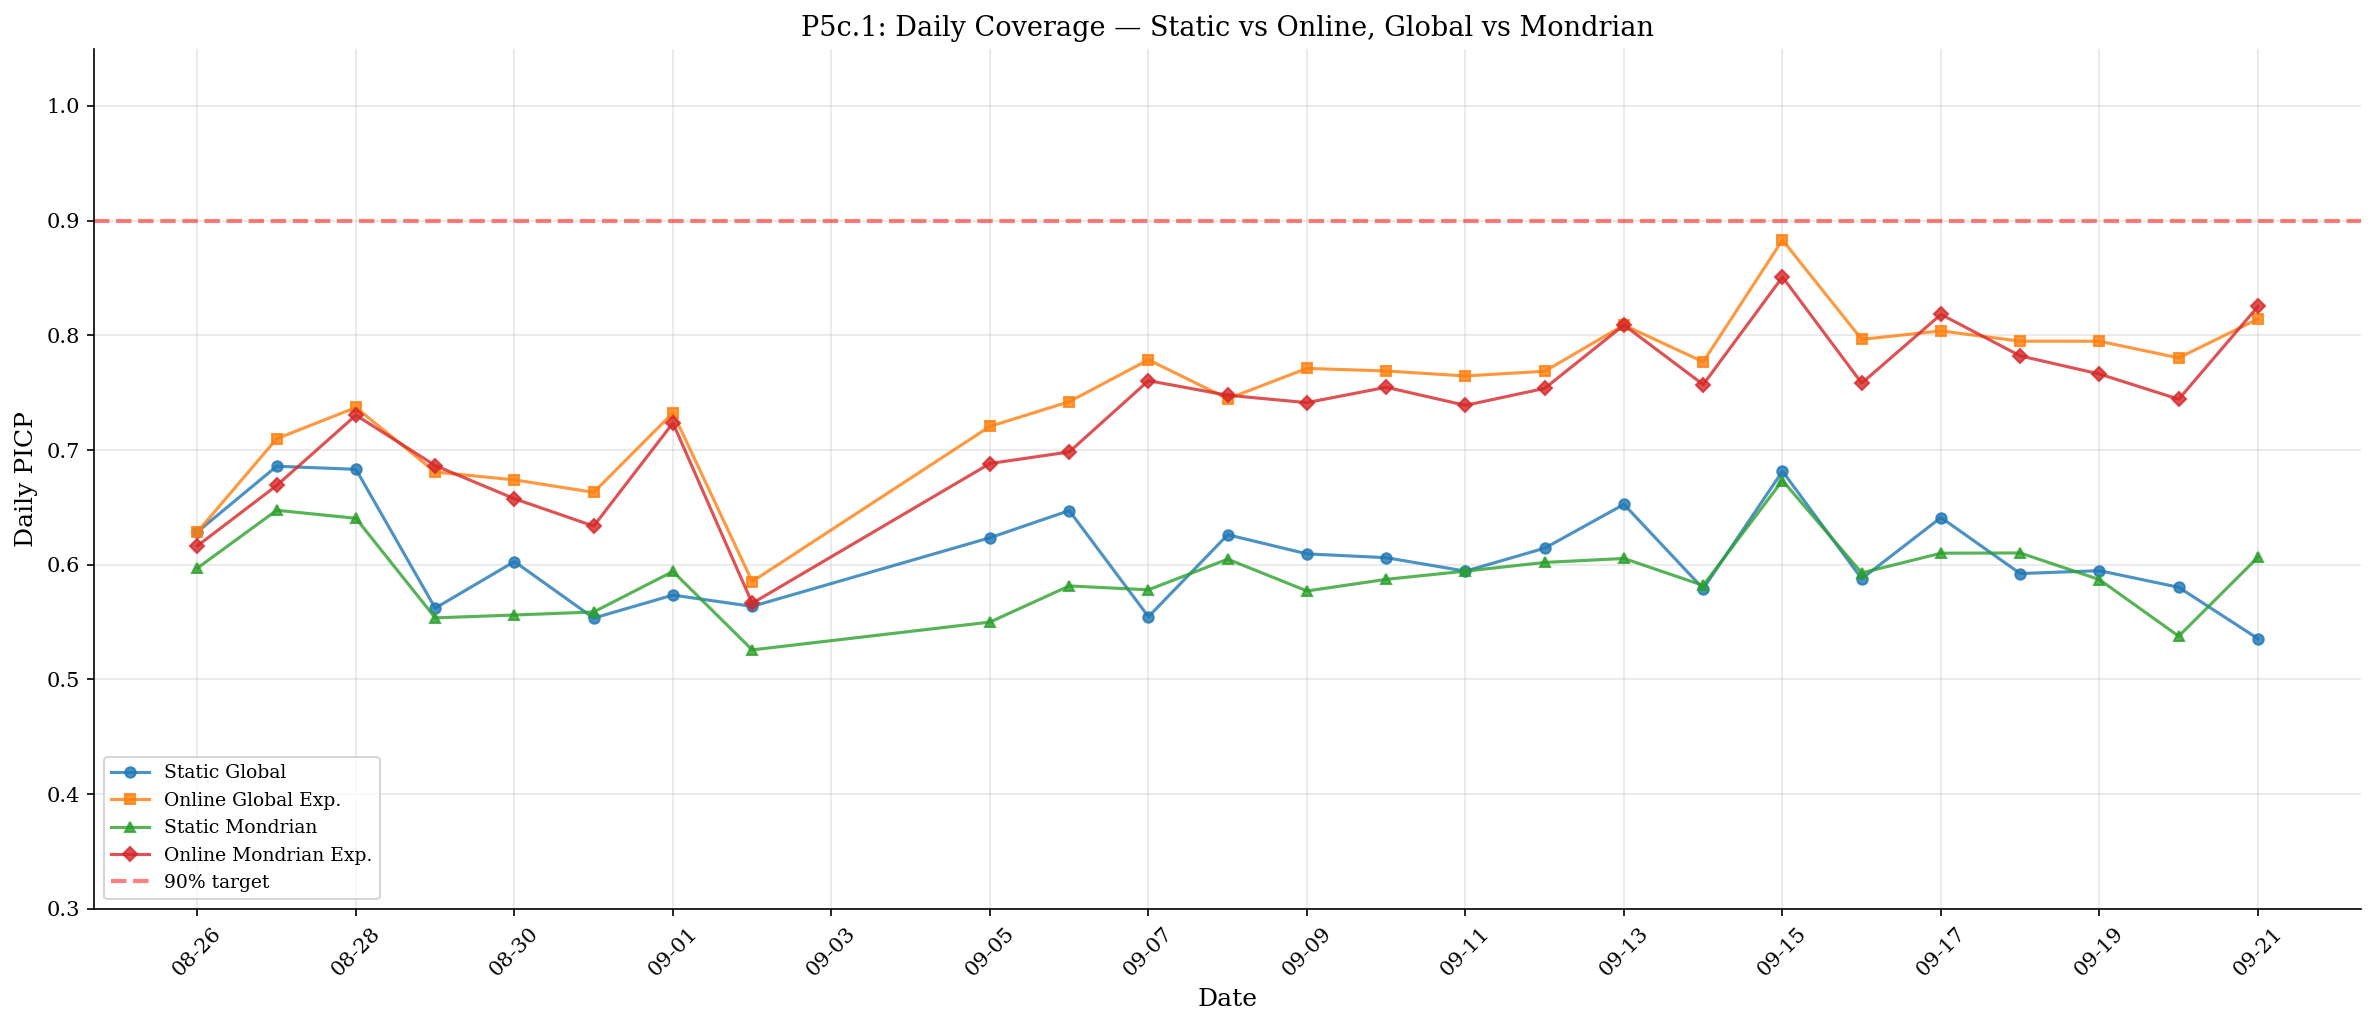

In [14]:
# Plot P5c.1: Daily PICP for key methods
set_thesis_style()
fig, ax = plt.subplots(figsize=(16, 7))

# Plot subset for clarity: Static Global, Online Global Exp., Static Mondrian, Online Mondrian Exp.
key_methods = ['Static Global', 'Online Global Exp.', 'Static Mondrian', 'Online Mondrian Exp.']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']

for name, color, marker in zip(key_methods, colors, markers):
    dm = daily_metrics[name]
    ax.plot(dm['date'], dm['PICP'], f'{marker}-', color=color,
            label=name, markersize=5, linewidth=1.5, alpha=0.8)

ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, linewidth=2, label='90% target')
ax.set_ylabel('Daily PICP')
ax.set_xlabel('Date')
ax.set_title('P5c.1: Daily Coverage — Static vs Online, Global vs Mondrian', fontsize=13)
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(0.3, 1.05)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5c_1_daily_coverage.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5c_1_daily_coverage.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5c.1

Plot P5c.1 shows the daily PICP trajectory for the four key methods. The static methods (circle, triangle) have fixed calibration and can only degrade over time. The online methods (square, diamond) adapt through recalibration. Comparing Global (blue/orange) vs Mondrian (green/red) at each level reveals whether conditional binning provides a visible day-to-day coverage improvement. The ideal trajectory tracks close to the 0.90 target line throughout the entire test period.

---
## Plot P5c.2: Daily Interval Width Comparison

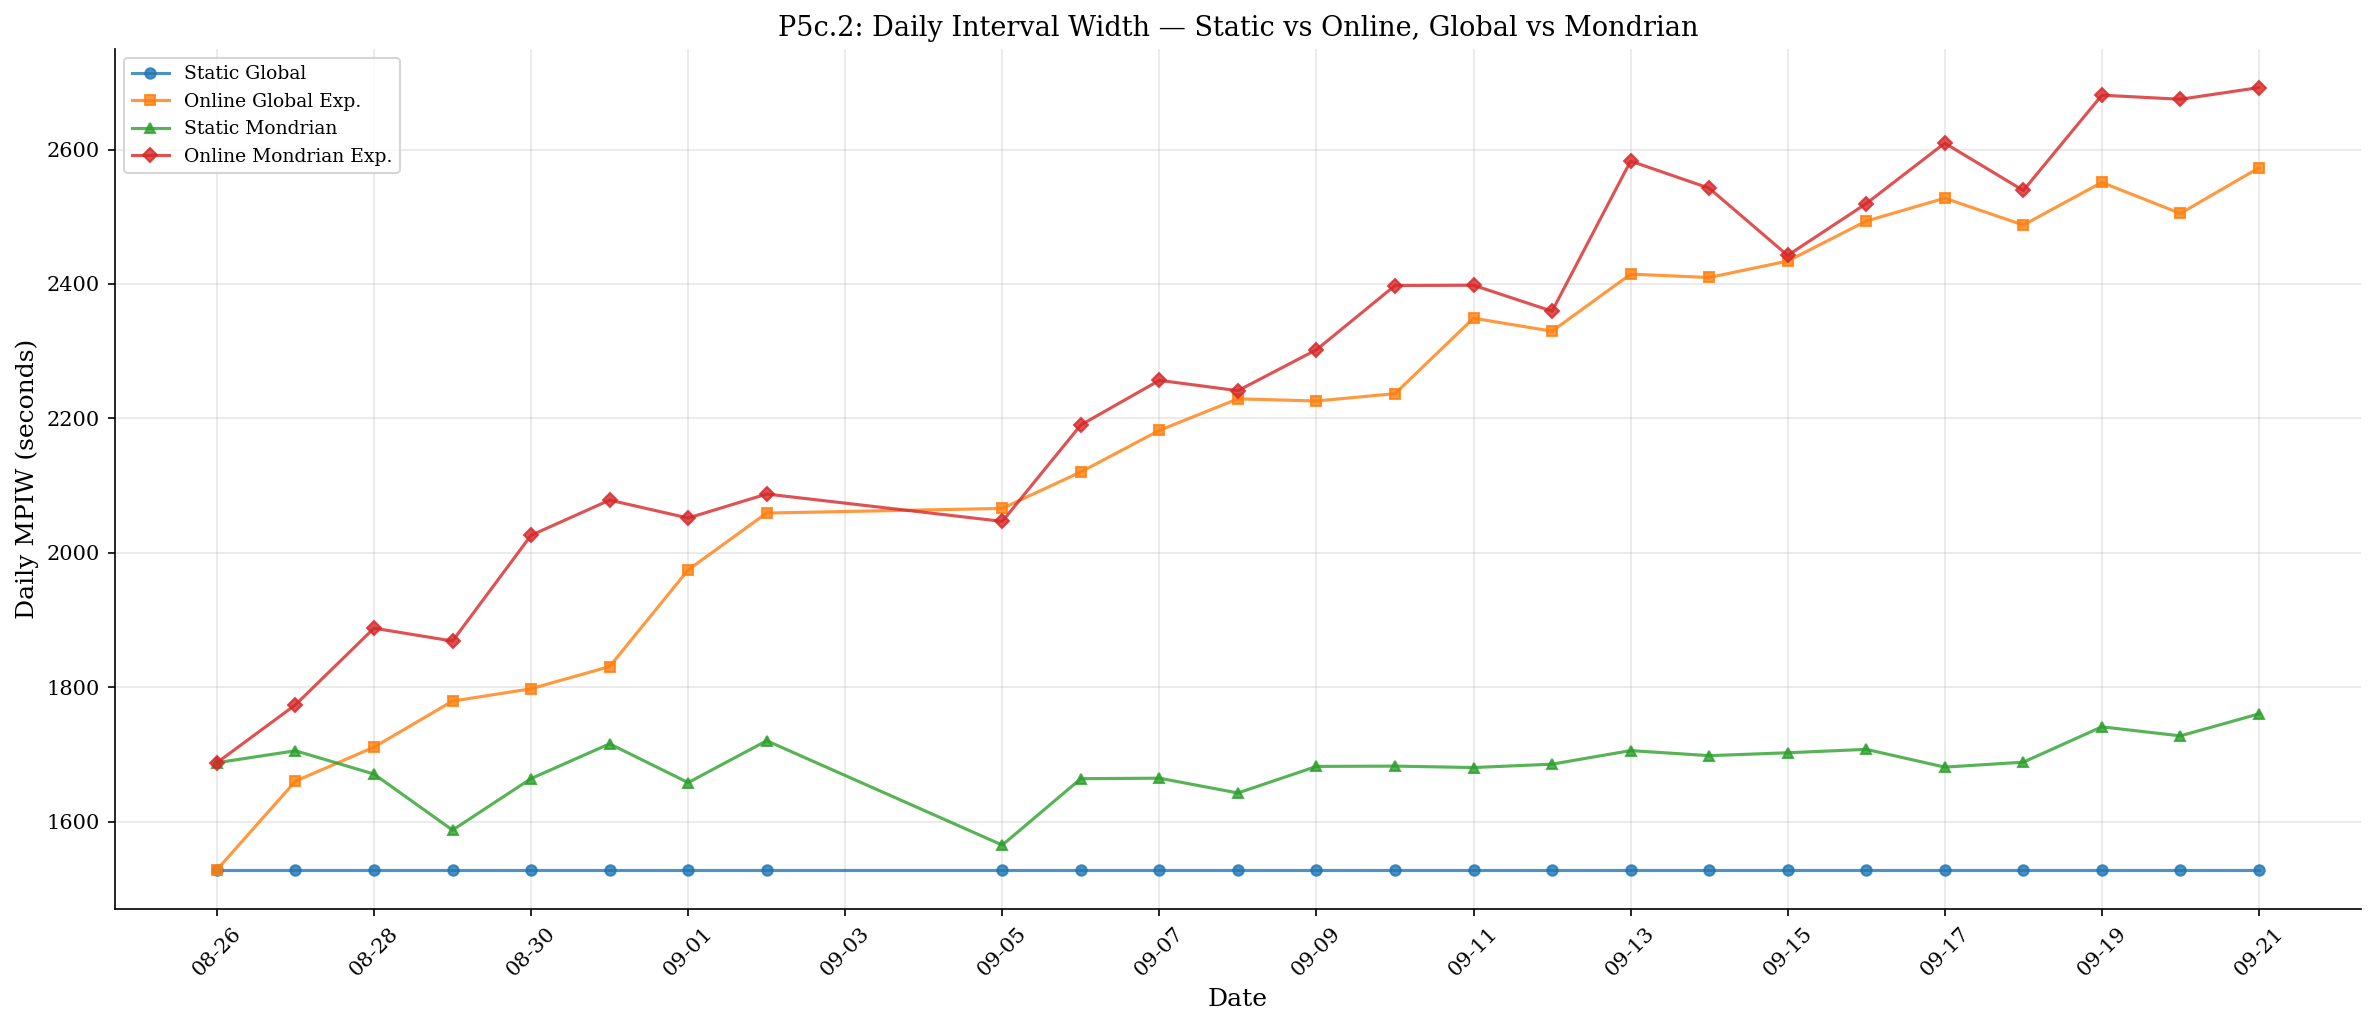

In [15]:
# Plot P5c.2: Daily MPIW
set_thesis_style()
fig, ax = plt.subplots(figsize=(16, 7))

for name, color, marker in zip(key_methods, colors, markers):
    dm = daily_metrics[name]
    ax.plot(dm['date'], dm['MPIW'], f'{marker}-', color=color,
            label=name, markersize=5, linewidth=1.5, alpha=0.8)

ax.set_ylabel('Daily MPIW (seconds)')
ax.set_xlabel('Date')
ax.set_title('P5c.2: Daily Interval Width — Static vs Online, Global vs Mondrian', fontsize=13)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5c_2_daily_width.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5c_2_daily_width.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5c.2

Plot P5c.2 shows the daily MPIW trajectories. Static methods produce constant-width intervals, while online methods adapt. Mondrian methods may show different average widths than Global because they redistribute the uncertainty budget across bins. The key insight is whether Mondrian methods achieve similar or better coverage (Plot P5c.1) with narrower average widths — indicating more efficient uncertainty quantification.

---
## Plot P5c.3: Coverage-Width Trade-off Scatter

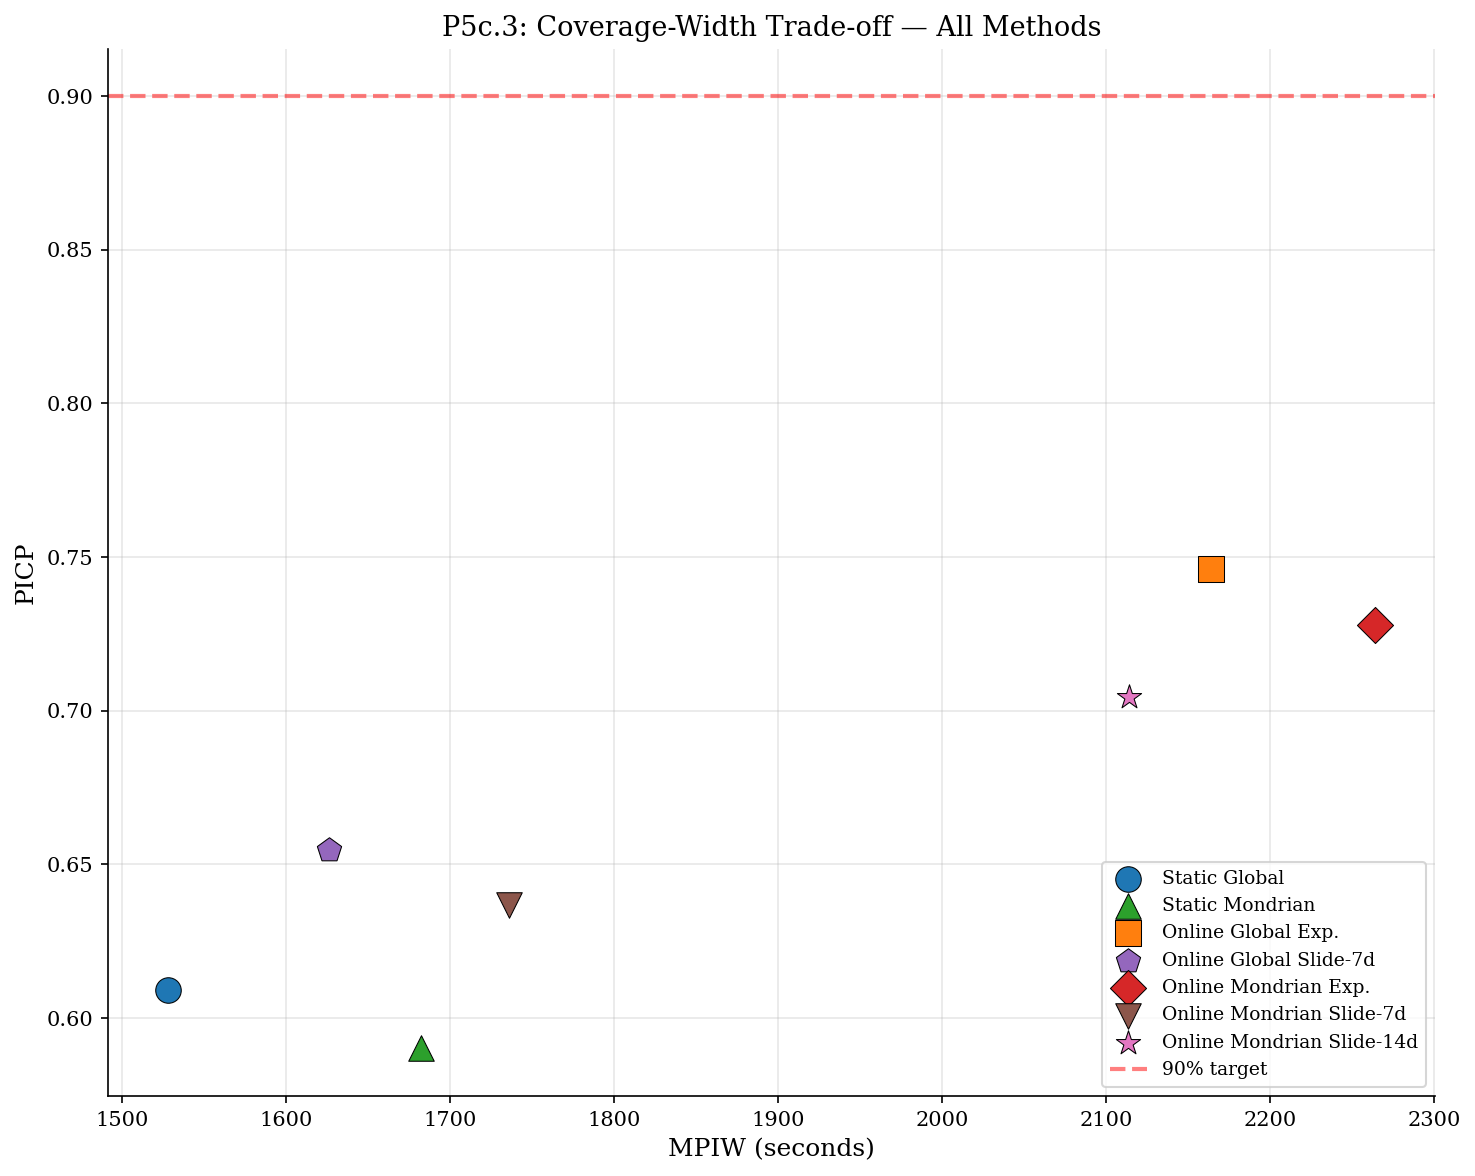

In [16]:
# Plot P5c.3: PICP vs MPIW scatter
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 8))

all_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd',
              '#d62728', '#8c564b', '#e377c2']
all_markers = ['o', '^', 's', 'p', 'D', 'v', '*']

for (name, m), color, marker in zip(methods.items(), all_colors, all_markers):
    met = m['metrics']
    ax.scatter(met['MPIW'], met['PICP'], s=150, c=color, marker=marker,
              label=name, edgecolors='black', linewidth=0.5, zorder=5)

ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, linewidth=2, label='90% target')
ax.set_xlabel('MPIW (seconds)', fontsize=12)
ax.set_ylabel('PICP', fontsize=12)
ax.set_title('P5c.3: Coverage-Width Trade-off — All Methods', fontsize=13)
ax.legend(fontsize=9, loc='best')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5c_3_tradeoff_scatter.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5c_3_tradeoff_scatter.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5c.3

Plot P5c.3 is the summary visualization — each method is a single point in the PICP × MPIW plane. Points closer to the top-left corner (high coverage, narrow intervals) are better. The 90% target line separates under-coverage (below) from adequate coverage (above). Methods that lie above the line and further left represent the best coverage-width trade-off. This plot directly reveals whether the combined Online + Mondrian approach achieves Pareto dominance over simpler alternatives.

---
## Plot P5c.4: Conditional Coverage — Online Mondrian by Bin

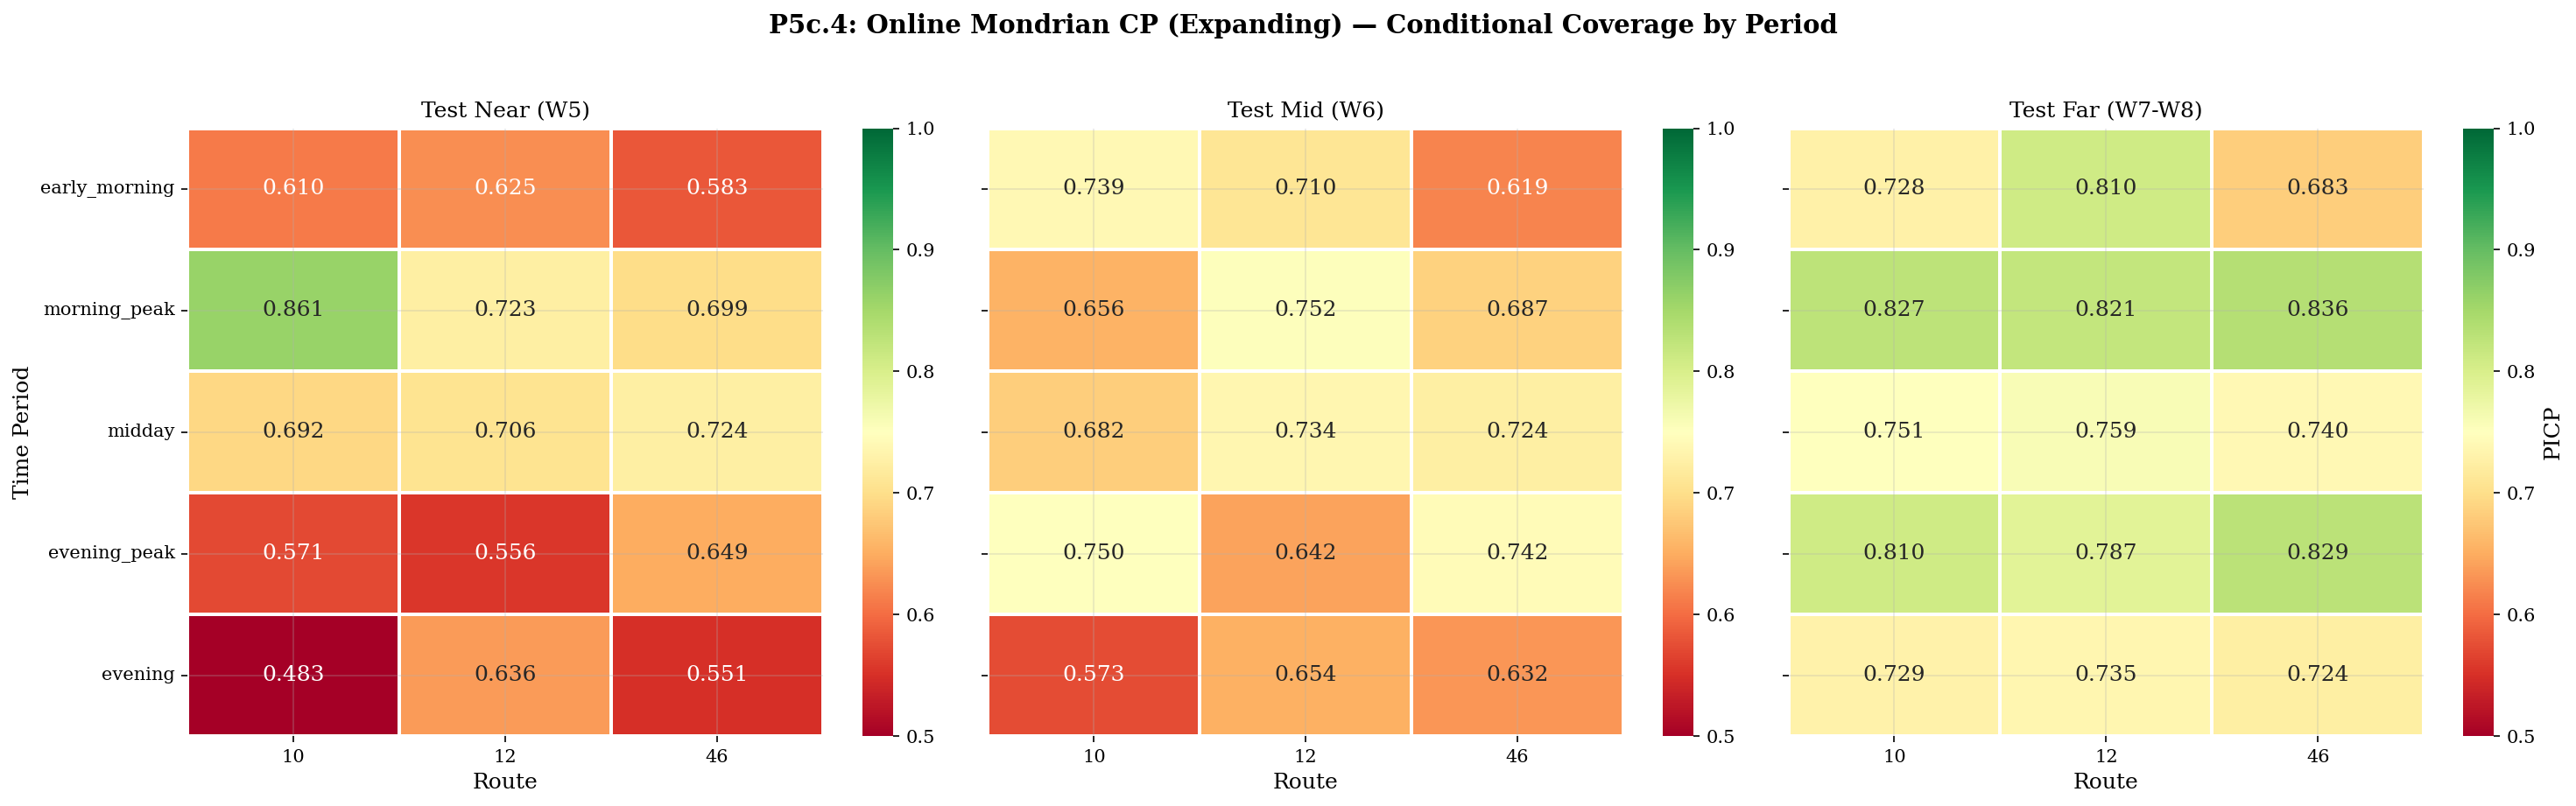

In [17]:
# Plot P5c.4: Per-bin conditional coverage for Online Mondrian Expanding
set_thesis_style()

cond_rows = []
for period in ['test_near', 'test_mid', 'test_far']:
    mask_period = periods_test == period
    for bid, (tp, route) in bin_labels.items():
        mask_bin = bins_test == bid
        mask = mask_period & mask_bin
        n = mask.sum()
        if n == 0:
            continue
        
        picp_om = compute_picp(y_test[mask], lower_om_exp[mask], upper_om_exp[mask])
        picp_og = compute_picp(y_test[mask], lower_og_exp[mask], upper_og_exp[mask])
        mpiw_om = compute_mpiw(lower_om_exp[mask], upper_om_exp[mask])
        mpiw_og = compute_mpiw(lower_og_exp[mask], upper_og_exp[mask])
        
        cond_rows.append({
            'Period': period, 'time_period': tp, 'route': route,
            'n': n,
            'Online_Global_PICP': picp_og, 'Online_Mondrian_PICP': picp_om,
            'Online_Global_MPIW': mpiw_og, 'Online_Mondrian_MPIW': mpiw_om,
        })

cond_online_df = pd.DataFrame(cond_rows)

# Heatmap: Online Mondrian conditional coverage
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, period_name, period_label in zip(
    axes,
    ['test_near', 'test_mid', 'test_far'],
    ['Test Near (W5)', 'Test Mid (W6)', 'Test Far (W7-W8)']
):
    period_data = cond_online_df[cond_online_df['Period'] == period_name]
    hm = period_data.pivot_table(values='Online_Mondrian_PICP', index='time_period', columns='route')
    tp_order = [tp for tp in MONDRIAN_VALID_TIME_PERIODS if tp in hm.index]
    hm = hm.reindex(tp_order)
    
    sns.heatmap(
        hm, annot=True, fmt='.3f', cmap='RdYlGn',
        vmin=0.50, vmax=1.0,
        linewidths=1, linecolor='white',
        cbar_kws={'label': 'PICP'} if ax == axes[-1] else {'label': ''},
        ax=ax
    )
    ax.set_title(period_label, fontsize=12)
    ax.set_ylabel('Time Period' if ax == axes[0] else '')
    ax.set_xlabel('Route')

fig.suptitle('P5c.4: Online Mondrian CP (Expanding) — Conditional Coverage by Period',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5c_4_online_mondrian_conditional.png'),
            dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5c_4_online_mondrian_conditional.pdf'),
            bbox_inches='tight')
plt.show()

### Interpretation — Plot P5c.4

Plot P5c.4 is the conditional coverage heatmap for the Online Mondrian CP (Expanding) method. Compared to the static Mondrian heatmap in Phase 4b, this should show improved and more stable coverage across bins, especially in test_mid and test_far where temporal drift is strongest. The combination of online recalibration (adapting the quantile over time) and Mondrian binning (adapting per category) provides the most fine-grained uncertainty quantification.

---
## 10. Statistical Significance

In [18]:
# Statistical tests: Online Global vs Online Mondrian (paired)
sig_rows = []

comparisons = [
    ('Online Global Exp.', 'Online Mondrian Exp.', y_pred_og_exp, lower_og_exp, upper_og_exp,
     y_pred_om_exp, lower_om_exp, upper_om_exp),
    ('Online Global Slide-7d', 'Online Mondrian Slide-7d', y_pred_og_s7, lower_og_s7, upper_og_s7,
     y_pred_om_s7, lower_om_s7, upper_om_s7),
]

for name_a, name_b, yp_a, lo_a, up_a, yp_b, lo_b, up_b in comparisons:
    covered_a = ((y_test >= lo_a) & (y_test <= up_a)).astype(int)
    covered_b = ((y_test >= lo_b) & (y_test <= up_b)).astype(int)
    
    # McNemar
    only_a = ((covered_a == 1) & (covered_b == 0)).sum()
    only_b = ((covered_a == 0) & (covered_b == 1)).sum()
    
    if only_a + only_b > 0:
        mcnemar_stat = (only_a - only_b)**2 / (only_a + only_b)
        mcnemar_p = 1 - stats.chi2.cdf(mcnemar_stat, df=1)
    else:
        mcnemar_stat, mcnemar_p = 0, 1.0
    
    # Winkler comparison
    w_a = up_a - lo_a
    below_a = y_test < lo_a
    above_a = y_test > up_a
    w_a[below_a] += (2/ALPHA) * (lo_a[below_a] - y_test[below_a])
    w_a[above_a] += (2/ALPHA) * (y_test[above_a] - up_a[above_a])
    
    w_b = up_b - lo_b
    below_b = y_test < lo_b
    above_b = y_test > up_b
    w_b[below_b] += (2/ALPHA) * (lo_b[below_b] - y_test[below_b])
    w_b[above_b] += (2/ALPHA) * (y_test[above_b] - up_b[above_b])
    
    diff = w_b - w_a
    if np.any(diff != 0):
        _, wilcox_p = wilcoxon(w_a, w_b)
    else:
        wilcox_p = 1.0
    
    sig_rows.append({
        'Comparison': f"{name_a} vs {name_b}",
        f'PICP ({name_a.split()[-1]})': covered_a.mean(),
        f'PICP ({name_b.split()[-1]})': covered_b.mean(),
        'McNemar p': mcnemar_p,
        'Wilcoxon p': wilcox_p,
        'Sig.': '***' if mcnemar_p < 0.001 else ('**' if mcnemar_p < 0.01 else ('*' if mcnemar_p < 0.05 else 'ns')),
    })

sig_df = pd.DataFrame(sig_rows)
display(sig_df.style.format({
    k: '{:.4f}' for k in sig_df.columns if 'PICP' in k or 'p' in k.lower()
}).set_caption('Table T5c.3: Statistical Significance — Global vs Mondrian Online CP'))

# Save
sig_latex = sig_df.to_latex(
    index=False, float_format='%.4f',
    caption='Statistical Significance — Global vs Mondrian Online CP',
    label='tab:t5c_3_significance'
)
with open(os.path.join(TABLE_DIR, 'T5c_3_significance.tex'), 'w') as f:
    f.write(sig_latex)
print(f"Saved: T5c_3_significance.tex")

ValueError: Unknown format code 'f' for object of type 'str'

Saved: T5c_3_significance.tex


### Interpretation — Table T5c.3

Table T5c.3 tests whether the coverage differences between Online Global CP and Online Mondrian CP are statistically significant. McNemar's test evaluates coverage (binary: covered or not) and the Wilcoxon signed-rank test evaluates interval quality (Winkler scores). Significance (p < 0.05) indicates that the methods produce meaningfully different prediction quality, ruling out sampling variability as the explanation.

---
## Plot P5c.5: Rolling Coverage — Online Global vs Online Mondrian

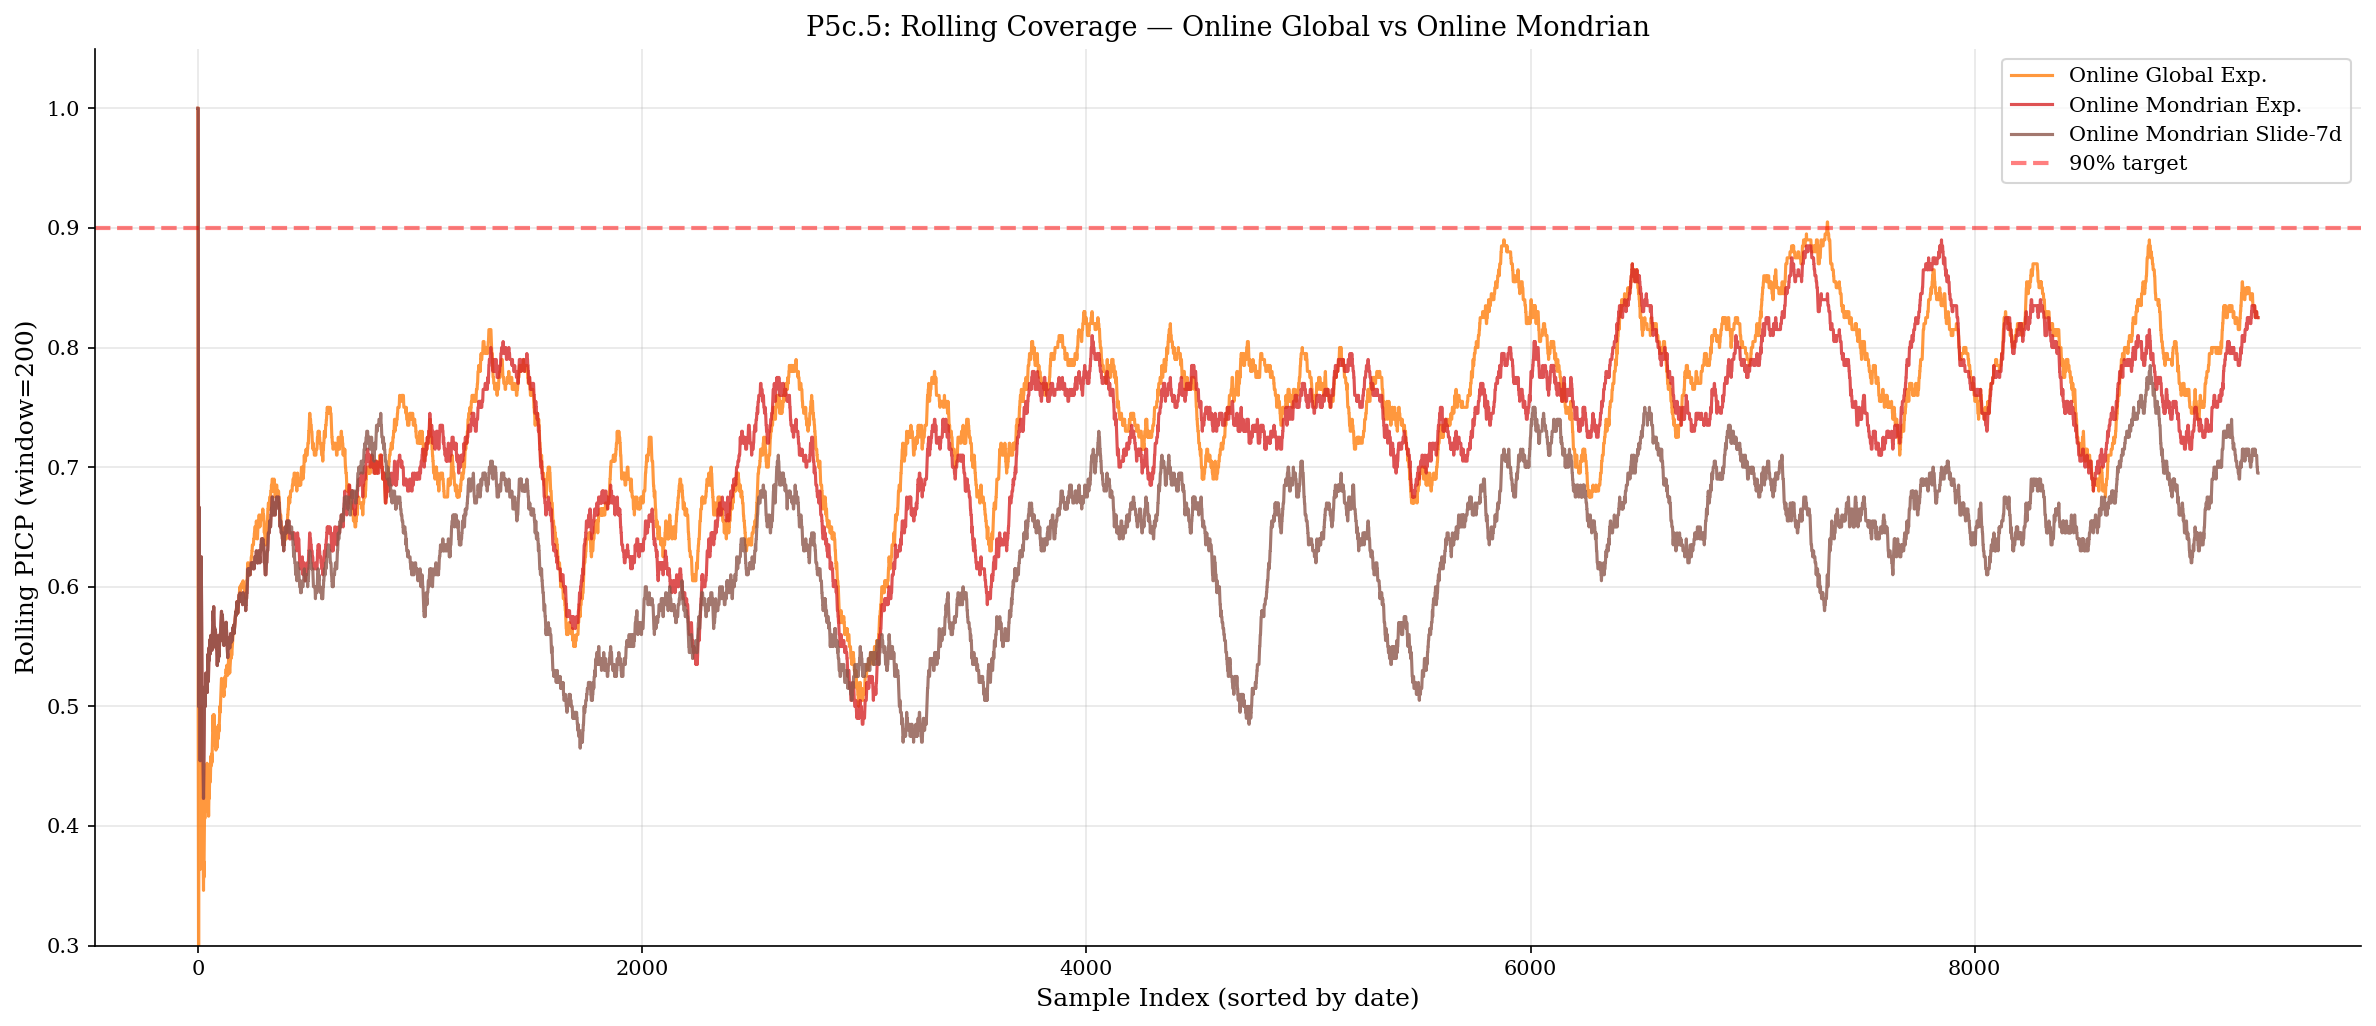

In [19]:
# Plot P5c.5: Rolling PICP comparison
ROLLING_WINDOW = 200
set_thesis_style()

fig, ax = plt.subplots(figsize=(16, 7))

rolling_methods = [
    ('Online Global Exp.', lower_og_exp, upper_og_exp, '#ff7f0e'),
    ('Online Mondrian Exp.', lower_om_exp, upper_om_exp, '#d62728'),
    ('Online Mondrian Slide-7d', lower_om_s7, upper_om_s7, '#8c564b'),
]

for name, lo, up, color in rolling_methods:
    rolling = compute_rolling_coverage(y_test, lo, up, dates_test, window_size=ROLLING_WINDOW)
    ax.plot(rolling['rolling_picp'].values, label=name, color=color, linewidth=1.5, alpha=0.8)

ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, linewidth=2, label='90% target')
ax.set_xlabel('Sample Index (sorted by date)')
ax.set_ylabel(f'Rolling PICP (window={ROLLING_WINDOW})')
ax.set_title(f'P5c.5: Rolling Coverage — Online Global vs Online Mondrian', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0.3, 1.05)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P5c_5_rolling_coverage.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P5c_5_rolling_coverage.pdf'), bbox_inches='tight')
plt.show()

### Interpretation — Plot P5c.5

Plot P5c.5 shows the rolling PICP (window=200 samples) over the full test stream. This reveals the fine-grained coverage dynamics: how quickly each method adapts to distribution changes, whether there are periods of sustained under-coverage, and whether Mondrian binning smooths out coverage fluctuations by ensuring per-category calibration. The Online Mondrian methods should exhibit less volatile rolling coverage if the per-bin calibration stabilizes each category independently.

---
## Experiment 2c Conclusion

In [20]:
print("=" * 70)
print("EXPERIMENT 2c SUMMARY — Online Mondrian CP")
print("=" * 70)
print(f"\nBinning: time_period × route (15 bins, night fallback)")
print(f"Confidence: {TARGET_COVERAGE*100:.0f}%")
print(f"\n{'Method':<30s} {'PICP':>8s} {'MPIW (s)':>10s} {'Winkler':>10s} {'Time (s)':>10s}")
print("-" * 70)
for name, m in methods.items():
    met = m['metrics']
    print(f"{name:<30s} {met['PICP']:>8.4f} {met['MPIW']:>10.1f} {met['Winkler_Score']:>10.1f} {m['time']:>10.1f}")

print("\n" + "=" * 70)
print("KEY FINDINGS:")
print("=" * 70)

# Find best method by Winkler
best_name = min(methods.keys(), key=lambda k: methods[k]['metrics']['Winkler_Score'])
best_met = methods[best_name]['metrics']
print(f"\nBest overall (Winkler): {best_name}")
print(f"  PICP={best_met['PICP']:.4f}, MPIW={best_met['MPIW']:.1f}s, Winkler={best_met['Winkler_Score']:.1f}")

EXPERIMENT 2c SUMMARY — Online Mondrian CP

Binning: time_period × route (15 bins, night fallback)
Confidence: 90%

Method                             PICP   MPIW (s)    Winkler   Time (s)
----------------------------------------------------------------------
Static Global                    0.6091     1528.3     9544.6       18.3
Static Mondrian                  0.5901     1682.3     9026.4       18.1
Online Global Exp.               0.7462     2163.8     7465.0       33.1
Online Global Slide-7d           0.6547     1626.3     8728.9       24.3
Online Mondrian Exp.             0.7280     2263.8     7089.4       38.6
Online Mondrian Slide-7d         0.6368     1736.0     8474.4       30.1
Online Mondrian Slide-14d        0.7044     2114.0     7518.6       34.5

KEY FINDINGS:

Best overall (Winkler): Online Mondrian Exp.
  PICP=0.7280, MPIW=2263.8s, Winkler=7089.4


---
## 11. Save Results

In [21]:
# Save comprehensive results

# 1. Per-sample predictions
results_df = pd.DataFrame({
    'date': dates_test,
    'period': periods_test,
    'y_true': y_test,
    'mondrian_bin': bins_test,
    # Static Global
    'pred_static_g': y_pred_static_g,
    'lower_static_g': lower_static_g,
    'upper_static_g': upper_static_g,
    # Static Mondrian
    'pred_static_m': y_pred_static_m,
    'lower_static_m': lower_static_m,
    'upper_static_m': upper_static_m,
    # Online Global Expanding
    'pred_og_exp': y_pred_og_exp,
    'lower_og_exp': lower_og_exp,
    'upper_og_exp': upper_og_exp,
    # Online Global Sliding-7d
    'pred_og_s7': y_pred_og_s7,
    'lower_og_s7': lower_og_s7,
    'upper_og_s7': upper_og_s7,
    # Online Mondrian Expanding
    'pred_om_exp': y_pred_om_exp,
    'lower_om_exp': lower_om_exp,
    'upper_om_exp': upper_om_exp,
    # Online Mondrian Sliding-7d
    'pred_om_s7': y_pred_om_s7,
    'lower_om_s7': lower_om_s7,
    'upper_om_s7': upper_om_s7,
    # Online Mondrian Sliding-14d
    'pred_om_s14': y_pred_om_s14,
    'lower_om_s14': lower_om_s14,
    'upper_om_s14': upper_om_s14,
})

# Add time_period and route
if 'time_period' in test_all.columns:
    results_df['time_period'] = test_all['time_period'].values
if 'route_short_name' in test_all.columns:
    results_df['route_short_name'] = test_all['route_short_name'].values

results_path = os.path.join(RESULTS_DIR, 'exp2c_mondrian_results.parquet')
results_df.to_parquet(results_path, index=False)
print(f"Saved predictions: {results_path} ({len(results_df):,} rows)")

# 2. Metrics summary as JSON
metrics_summary = {
    'experiment': 'Phase5c_Exp2c_Online_Mondrian_CP',
    'target_coverage': TARGET_COVERAGE,
    'n_test_samples': int(len(y_test)),
    'n_cal_samples_initial': int(len(y_cal)),
    'binning_strategy': 'time_period × route_short_name (15 bins, night fallback)',
    'methods': {}
}

for name, m in methods.items():
    met = m['metrics']
    metrics_summary['methods'][name] = {
        k: float(v) if isinstance(v, (np.floating, float, np.integer, int)) else v
        for k, v in met.items()
    }
    metrics_summary['methods'][name]['time_seconds'] = float(m['time'])

metrics_path = os.path.join(RESULTS_DIR, 'exp2c_mondrian_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2, default=str)
print(f"Saved metrics: {metrics_path}")

# 3. Conditional coverage
if len(cond_rows) > 0:
    cond_path = os.path.join(RESULTS_DIR, 'exp2c_conditional_coverage.csv')
    cond_online_df.to_csv(cond_path, index=False)
    print(f"Saved conditional coverage: {cond_path}")

print("\n" + u"\u2713" + " Experiment 2c results saved successfully.")

Saved predictions: ../outputs/processed_data/phase5c/exp2c_mondrian_results.parquet (9,276 rows)
Saved metrics: ../outputs/processed_data/phase5c/exp2c_mondrian_metrics.json
Saved conditional coverage: ../outputs/processed_data/phase5c/exp2c_conditional_coverage.csv

✓ Experiment 2c results saved successfully.
